# Commodity Bubble Detection -- ML Pipeline

Classifies commodity metal price bubbles using three ML models with proper **time-series cross-validation**.

**Key corrections** over the original R pipeline:
- Time-series CV (expanding window) instead of random k-fold -- prevents future data leakage
- Consistent class imbalance handling (balanced weights) across all models
- Identical feature set for all three models -- fair comparison
- Early stopping for LightGBM

**Ground truth:** GSADF bubble labels from full-sample detection (treated as given).

**Models:** LASSO (linear benchmark) | Random Forest | LightGBM

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os, warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import roc_auc_score, confusion_matrix, roc_curve
from sklearn.preprocessing import StandardScaler
import lightgbm as lgb
import shap

plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.facecolor'] = 'white'
os.makedirs('outputs', exist_ok=True)
print('All packages loaded.')

All packages loaded.


## 1. Load Data

Load `df_master` generated by `R/metals30_data_prep.R` (semicolon-separated, comma decimal).

In [2]:
df_master = pd.read_csv('../R/df_master.csv', sep=';', decimal=',', index_col=0)
df_master['Date'] = pd.to_datetime(df_master['Date'])
df_master = df_master.sort_values('Date').reset_index(drop=True)

bubble_cols = [c for c in df_master.columns if c.endswith('_BD')]
numeric_cols = [c for c in df_master.select_dtypes(include='number').columns
                if c not in bubble_cols]

print('Dataset: {} rows x {} columns'.format(df_master.shape[0], df_master.shape[1]))
print('Period:  {} to {}'.format(df_master['Date'].min().date(), df_master['Date'].max().date()))
print()
print('Metals:       ', [c for c in numeric_cols if c in ['CODALY','CUDALY','LIDALY','NIDALY']])
print('Macro/Market: ', [c for c in numeric_cols if c not in ['CODALY','CUDALY','LIDALY','NIDALY']])
print()
print('Bubble prevalence:')
for col in bubble_cols:
    n = int(df_master[col].sum())
    pct = 100.0 * n / len(df_master)
    metal = col.replace('_BD', '')
    print('  {:8s}: {:4d} days ({:.1f}%)'.format(metal, n, pct))

Dataset: 2152 rows x 21 columns
Period:  2017-05-10 to 2025-10-31

Metals:        ['CODALY', 'CUDALY', 'LIDALY', 'NIDALY']
Macro/Market:  ['OIL_WTI', 'GAS_HHUB', 'USD_INDEX', 'VIX', 'YIELD_10Y', 'GOLD_FUT', 'MSCI_ETF', 'MSCI_EM', 'SP500', 'QCLN', 'C_CHR', 'C_US']

Bubble prevalence:
  CODALY  :  230 days (10.7%)
  CUDALY  :   39 days (1.8%)
  LIDALY  : 1089 days (50.6%)
  NIDALY  :   26 days (1.2%)


## 2. Bubble Periods

Price series with GSADF-detected bubble episodes shaded in purple.

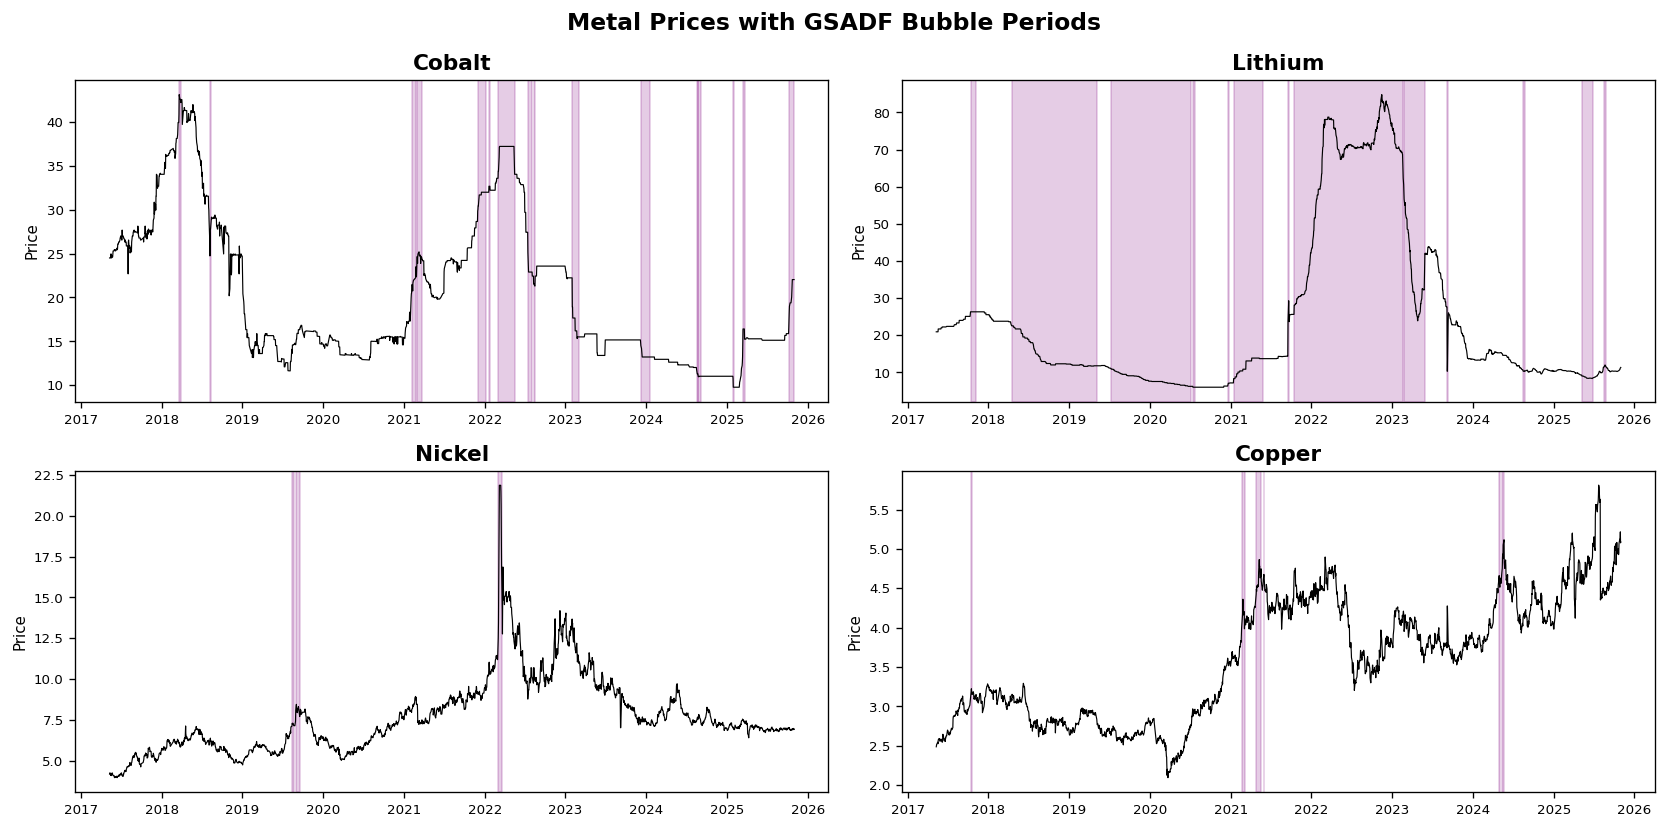

In [3]:
metal_map = {
    'Cobalt':  ('CODALY', 'CODALY_BD'),
    'Lithium': ('LIDALY', 'LIDALY_BD'),
    'Nickel':  ('NIDALY', 'NIDALY_BD'),
    'Copper':  ('CUDALY', 'CUDALY_BD'),
}

fig, axes = plt.subplots(2, 2, figsize=(14, 7))
for idx, (metal, (pcol, dcol)) in enumerate(metal_map.items()):
    ax = axes.flat[idx]
    dates = df_master['Date']
    ax.plot(dates, df_master[pcol], color='black', lw=0.7)
    
    # Shade bubble periods
    bub = df_master[dcol].values
    in_b = False
    for i in range(len(bub)):
        if bub[i] == 1 and not in_b:
            start = dates.iloc[i]
            in_b = True
        elif (bub[i] == 0 or i == len(bub) - 1) and in_b:
            ax.axvspan(start, dates.iloc[i], color='purple', alpha=0.2)
            in_b = False
    
    ax.set_title(metal, fontsize=13, fontweight='bold')
    ax.tick_params(labelsize=8)
    ax.set_ylabel('Price', fontsize=9)

plt.suptitle('Metal Prices with GSADF Bubble Periods', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/bubble_timelines.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

## 3. Feature Engineering

For each metal, build a feature matrix with:
- **Log-returns** and **10-day rolling volatility** for every numeric series (including VIX)
- **Lagged price levels** for macro/market variables
- **Peer bubble dummies** (other metals' bubble flags)
- Everything **lagged by 1 day** to prevent look-ahead bias


In [4]:
def prepare_ml_data(target_col, df_master):
    '''Build lagged feature matrix for bubble classification.'''
    target_dummy = target_col + '_BD'
    bubble_cols = [c for c in df_master.columns if c.endswith('_BD')]
    num_cols = [c for c in df_master.select_dtypes(include='number').columns
                if c not in bubble_cols]
    peer_dummies = [c for c in bubble_cols if c != target_dummy]

    df = df_master[['Date'] + num_cols + bubble_cols].copy()
    df = df.sort_values('Date').reset_index(drop=True)

    # Log-returns and 10-day rolling volatility
    for col in num_cols:
        safe = df[col].clip(lower=0.001)
        lr = np.log(safe).diff()
        df[col + '_Ret'] = lr
        df[col + '_Vol'] = lr.rolling(10).std()

    # Lag ALL features by 1 day
    lagged = {}
    for c in [c for c in df.columns if c.endswith('_Ret')]:
        lagged[c + '_Lag1'] = df[c].shift(1)
    for c in [c for c in df.columns if c.endswith('_Vol')]:
        lagged[c + '_Lag1'] = df[c].shift(1)
    for c in num_cols:
        lagged[c + '_Level_Lag1'] = df[c].shift(1)
    for c in peer_dummies:
        lagged[c + '_Lag1'] = df[c].shift(1).fillna(0)

    df_out = pd.DataFrame(lagged, index=df.index)
    df_out['Date'] = df['Date']
    df_out['Target'] = df[target_dummy].astype(int)
    return df_out.dropna().reset_index(drop=True)

# Quick test
df_test = prepare_ml_data('CODALY', df_master)
feats = [c for c in df_test.columns if c not in ['Date', 'Target']]
print('Features: {} | Rows: {} | Bubble days: {}'.format(
    len(feats), len(df_test), df_test['Target'].sum()))

Features: 51 | Rows: 2141 | Bubble days: 230


## 4. Evaluation Framework

**Expanding-window time-series CV** (5 splits). Each fold trains on all data up to a cutpoint,
then tests on the next chronological block. The model never sees future data during training.

All models use **balanced class weights** to handle the rarity of bubble events.

In [5]:
def compute_metrics(y_true, y_prob, threshold=0.5):
    '''Compute classification metrics from predicted probabilities.'''
    y_pred = (y_prob >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    sens = tp / (tp + fn) if (tp + fn) > 0 else 0
    spec = tn / (tn + fp) if (tn + fp) > 0 else 0
    prec = tp / (tp + fp) if (tp + fp) > 0 else 0
    auc = roc_auc_score(y_true, y_prob) if len(np.unique(y_true)) > 1 else 0.5
    return {
        'Bal. Accuracy': round((sens + spec) / 2, 3),
        'Sensitivity': round(sens, 3),
        'Specificity': round(spec, 3),
        'Precision': round(prec, 3),
        'AUC': round(auc, 3),
        'Bubbles': '{}/{}'.format(tp, tp + fn)
    }


def run_timeseries_cv(X, y, model_fn, n_splits=5, scale=False):
    '''Expanding-window time-series CV. Training always precedes testing.'''
    tscv = TimeSeriesSplit(n_splits=n_splits)
    all_preds, all_true = [], []

    for train_idx, test_idx in tscv.split(X):
        X_tr, X_te = X[train_idx], X[test_idx]
        y_tr, y_te = y[train_idx], y[test_idx]
        if y_tr.sum() < 5:
            continue
        if scale:
            sc = StandardScaler()
            X_tr = sc.fit_transform(X_tr)
            X_te = sc.transform(X_te)
        model = model_fn()
        model.fit(X_tr, y_tr)
        all_preds.append(model.predict_proba(X_te)[:, 1])
        all_true.append(y_te)

    return np.concatenate(all_preds), np.concatenate(all_true)


# Storage
cv_preds = {}  # (metal, model_name) -> (y_true, y_prob)
metal_configs = {
    'Cobalt': 'CODALY', 'Lithium': 'LIDALY',
    'Nickel': 'NIDALY', 'Copper': 'CUDALY'
}
print('CV framework ready: expanding-window splits (no future leakage).')

CV framework ready: expanding-window splits (no future leakage).


## 5. LASSO (Linear Benchmark) + Hyperparameter Tuning

L1-penalized logistic regression. The loss function is:

$$\min_{\beta} \; -\frac{1}{n}\sum_{i=1}^n \big[ y_i \log \hat{p}_i + (1-y_i)\log(1-\hat{p}_i) \big] + \frac{1}{C}\|\beta\|_1$$

where $C$ is the **inverse regularization strength** — smaller $C$ = more sparsity.

**Tuned:** $C \in \{0.001, 0.01, 0.1, 1, 10\}$ via time-series CV, optimizing AUC.

In [6]:
results_lasso = {}
lasso_models = {}
lasso_best_params = {}

C_grid = [0.001, 0.01, 0.1, 1.0, 10.0]

print('LASSO — Tuning C via Time-Series CV')
print('=' * 55)

for metal, col in metal_configs.items():
    df_ml = prepare_ml_data(col, df_master)
    feats = [c for c in df_ml.columns if c not in ['Date', 'Target']]
    X, y = df_ml[feats].values, df_ml['Target'].values

    if y.sum() < 10:
        print('  {}: skipped (too few bubbles)'.format(metal))
        continue

    # Grid search over C
    best_auc, best_C = -1, 1.0
    for C_val in C_grid:
        def make_lasso_c(c=C_val):
            return LogisticRegression(
                penalty='l1', solver='saga', C=c,
                class_weight='balanced', max_iter=10000, random_state=42)
        try:
            preds_c, true_c = run_timeseries_cv(X, y, make_lasso_c, n_splits=5, scale=True)
            auc_c = roc_auc_score(true_c, preds_c) if len(np.unique(true_c)) > 1 else 0.5
            if auc_c > best_auc:
                best_auc, best_C = auc_c, C_val
        except:
            continue

    # Final run with best C
    def make_lasso_best(c=best_C):
        return LogisticRegression(
            penalty='l1', solver='saga', C=c,
            class_weight='balanced', max_iter=10000, random_state=42)

    preds, true = run_timeseries_cv(X, y, make_lasso_best, n_splits=5, scale=True)
    metrics = compute_metrics(true, preds)
    results_lasso[metal] = metrics
    lasso_best_params[metal] = {'C': best_C}
    cv_preds[(metal, 'LASSO')] = (true, preds)

    # Full model for coefficient analysis
    sc = StandardScaler()
    full_model = make_lasso_best()
    full_model.fit(sc.fit_transform(X), y)
    lasso_models[metal] = {'model': full_model, 'features': feats, 'scaler': sc}

    n_nz = int(np.sum(full_model.coef_[0] != 0))
    print('  {}: AUC={:.3f}  Bal.Acc={:.3f}  Bubbles={}  (C={}, non-zero: {})'.format(
        metal, metrics['AUC'], metrics['Bal. Accuracy'], metrics['Bubbles'], best_C, n_nz))

LASSO — Tuning C via Time-Series CV
  Cobalt: AUC=0.517  Bal.Acc=0.461  Bubbles=52/222  (C=0.1, non-zero: 31)
  Lithium: AUC=0.698  Bal.Acc=0.776  Bubbles=801/926  (C=0.001, non-zero: 0)
  Nickel: AUC=0.985  Bal.Acc=0.873  Bubbles=11/11  (C=0.1, non-zero: 20)
  Copper: AUC=0.513  Bal.Acc=0.398  Bubbles=0/9  (C=10.0, non-zero: 50)


## 6. Random Forest + Hyperparameter Tuning

Ensemble of $B$ decision trees. Each tree $b$ trains on a bootstrap sample and considers $\sqrt{p}$ random features at each split. The ensemble prediction is:

$$\hat{p}(x) = \frac{1}{B}\sum_{b=1}^{B} T_b(x)$$

**Tuned via randomized search** (50 draws from the grid, scored by AUC on time-series CV):
- `max_depth` ∈ {5, 10, 15, 20, None} — tree complexity
- `min_samples_leaf` ∈ {1, 5, 10, 25} — minimum observations per leaf
- `max_features` ∈ {`'sqrt'`, `'log2'`, 0.3} — feature subsampling

In [7]:
from itertools import product
import random

results_rf = {}
rf_models = {}
rf_best_params = {}

rf_param_grid = {
    'max_depth': [5, 10, 15, 20, None],
    'min_samples_leaf': [1, 5, 10, 25],
    'max_features': ['sqrt', 'log2', 0.3],
}

# Generate all combos, sample 20 for speed (randomized search)
all_combos = [dict(zip(rf_param_grid.keys(), v))
              for v in product(*rf_param_grid.values())]
random.seed(42)
rf_candidates = random.sample(all_combos, min(20, len(all_combos)))

print('Random Forest — Randomized Search ({} configs)'.format(len(rf_candidates)))
print('=' * 55)

for metal, col in metal_configs.items():
    df_ml = prepare_ml_data(col, df_master)
    feats = [c for c in df_ml.columns if c not in ['Date', 'Target']]
    X, y = df_ml[feats].values, df_ml['Target'].values

    if y.sum() < 10:
        print('  {}: skipped'.format(metal))
        continue

    best_auc, best_params = -1, {}
    for params in rf_candidates:
        def make_rf_p(p=params):
            return RandomForestClassifier(
                n_estimators=500, class_weight='balanced',
                random_state=42, n_jobs=-1, **p)
        try:
            preds_p, true_p = run_timeseries_cv(X, y, make_rf_p, n_splits=5)
            auc_p = roc_auc_score(true_p, preds_p) if len(np.unique(true_p)) > 1 else 0.5
            if auc_p > best_auc:
                best_auc, best_params = auc_p, params
        except:
            continue

    # Final run with best params
    def make_rf_best(p=best_params):
        return RandomForestClassifier(
            n_estimators=500, class_weight='balanced',
            random_state=42, n_jobs=-1, **p)

    preds, true = run_timeseries_cv(X, y, make_rf_best, n_splits=5)
    metrics = compute_metrics(true, preds)
    results_rf[metal] = metrics
    rf_best_params[metal] = best_params
    cv_preds[(metal, 'Random Forest')] = (true, preds)

    # Full model for feature importance
    full_model = make_rf_best()
    full_model.fit(X, y)
    rf_models[metal] = {'model': full_model, 'features': feats, 'X': X, 'y': y}

    print('  {}: AUC={:.3f}  Bal.Acc={:.3f}  Bubbles={}  {}'.format(
        metal, metrics['AUC'], metrics['Bal. Accuracy'], metrics['Bubbles'],
        {k: v for k, v in best_params.items()}))

Random Forest — Randomized Search (20 configs)
  Cobalt: AUC=0.539  Bal.Acc=0.517  Bubbles=9/222  {'max_depth': 15, 'min_samples_leaf': 25, 'max_features': 'log2'}
  Lithium: AUC=0.507  Bal.Acc=0.609  Bubbles=799/926  {'max_depth': 5, 'min_samples_leaf': 1, 'max_features': 0.3}
  Nickel: AUC=0.730  Bal.Acc=0.500  Bubbles=0/11  {'max_depth': 10, 'min_samples_leaf': 5, 'max_features': 0.3}
  Copper: AUC=0.316  Bal.Acc=0.481  Bubbles=0/9  {'max_depth': None, 'min_samples_leaf': 10, 'max_features': 0.3}


## 7. LightGBM + Hyperparameter Tuning

Gradient boosting minimizes the loss sequentially. At round $t$, a new tree $f_t$ is added:

$$F_t(x) = F_{t-1}(x) + \eta \cdot f_t(x)$$

where $\eta$ is the learning rate. Regularization via L1 ($\lambda_1$) and L2 ($\lambda_2$) on leaf weights, plus structural constraints (`num_leaves`, `max_depth`, `min_data_in_leaf`).

**Tuned via randomized search** (30 draws) with early stopping per fold:
- `num_leaves` ∈ {15, 31, 63} — tree complexity
- `max_depth` ∈ {-1, 5, 10} — depth limit (-1 = no limit)
- `learning_rate` ∈ {0.01, 0.05, 0.1}
- `lambda_l1`, `lambda_l2` ∈ {0, 0.1, 1.0, 5.0} — leaf weight regularization
- `min_data_in_leaf` ∈ {5, 20, 50} — prevents fitting noise

In [8]:
results_lgbm = {}
lgbm_models = {}
lgbm_best_params = {}

lgb_base = {
    'objective': 'binary',
    'metric': 'auc',
    'is_unbalance': True,
    'feature_fraction': 0.8,
    'bagging_fraction': 0.8,
    'bagging_freq': 5,
    'verbosity': -1,
    'seed': 42,
}

lgb_tune_grid = {
    'num_leaves': [15, 31, 63],
    'max_depth': [-1, 5, 10],
    'learning_rate': [0.01, 0.05, 0.1],
    'lambda_l1': [0, 0.1, 1.0, 5.0],
    'lambda_l2': [0, 0.1, 1.0, 5.0],
    'min_data_in_leaf': [5, 20, 50],
}

all_lgb_combos = [dict(zip(lgb_tune_grid.keys(), v))
                  for v in product(*lgb_tune_grid.values())]
random.seed(42)
lgb_candidates = random.sample(all_lgb_combos, min(30, len(all_lgb_combos)))


def run_lgbm_cv(X, y, params, n_splits=5):
    '''LightGBM time-series CV with early stopping. Returns (preds, true).'''
    tscv = TimeSeriesSplit(n_splits=n_splits)
    all_preds, all_true, iters = [], [], []

    for train_idx, test_idx in tscv.split(X):
        X_tr, X_te = X[train_idx], X[test_idx]
        y_tr, y_te = y[train_idx], y[test_idx]
        if y_tr.sum() < 5:
            continue

        val_n = max(int(len(X_tr) * 0.2), 50)
        X_val, y_val = X_tr[-val_n:], y_tr[-val_n:]
        X_tr_inner, y_tr_inner = X_tr[:-val_n], y_tr[:-val_n]

        d_train = lgb.Dataset(X_tr_inner, y_tr_inner)
        d_val = lgb.Dataset(X_val, y_val, reference=d_train)

        bst = lgb.train(
            params, d_train, num_boost_round=500,
            valid_sets=[d_val],
            callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(-1)])

        all_preds.append(bst.predict(X_te))
        all_true.append(y_te)
        iters.append(bst.best_iteration)

    return np.concatenate(all_preds), np.concatenate(all_true), iters


print('LightGBM — Randomized Search ({} configs, early stopping)'.format(len(lgb_candidates)))
print('=' * 55)

for metal, col in metal_configs.items():
    df_ml = prepare_ml_data(col, df_master)
    feats = [c for c in df_ml.columns if c not in ['Date', 'Target']]
    X, y = df_ml[feats].values, df_ml['Target'].values

    if y.sum() < 10:
        print('  {}: skipped'.format(metal))
        continue

    best_auc, best_hp = -1, {}
    for hp in lgb_candidates:
        params = {**lgb_base, **hp}
        try:
            preds_hp, true_hp, _ = run_lgbm_cv(X, y, params, n_splits=5)
            auc_hp = roc_auc_score(true_hp, preds_hp) if len(np.unique(true_hp)) > 1 else 0.5
            if auc_hp > best_auc:
                best_auc, best_hp = auc_hp, hp
        except:
            continue

    # Final run with best params
    best_params = {**lgb_base, **best_hp}
    preds_arr, true_arr, best_iters = run_lgbm_cv(X, y, best_params, n_splits=5)
    metrics = compute_metrics(true_arr, preds_arr)
    results_lgbm[metal] = metrics
    lgbm_best_params[metal] = best_hp
    cv_preds[(metal, 'LightGBM')] = (true_arr, preds_arr)

    # Full model for SHAP
    d_full = lgb.Dataset(X, y)
    bst_full = lgb.train(best_params, d_full, num_boost_round=int(np.mean(best_iters)))
    lgbm_models[metal] = {'model': bst_full, 'features': feats, 'X': X, 'y': y}

    avg_iter = int(np.mean(best_iters))
    print('  {}: AUC={:.3f}  Bal.Acc={:.3f}  Bubbles={}  (iters: {})'.format(
        metal, metrics['AUC'], metrics['Bal. Accuracy'], metrics['Bubbles'], avg_iter))
    print('        best: lr={}, leaves={}, depth={}, l1={}, l2={}, min_leaf={}'.format(
        best_hp.get('learning_rate'), best_hp.get('num_leaves'),
        best_hp.get('max_depth'), best_hp.get('lambda_l1'),
        best_hp.get('lambda_l2'), best_hp.get('min_data_in_leaf')))

LightGBM — Randomized Search (30 configs, early stopping)
  Cobalt: AUC=0.728  Bal.Acc=0.500  Bubbles=0/222  (iters: 3)
        best: lr=0.05, leaves=31, depth=-1, l1=0.1, l2=5.0, min_leaf=5
  Lithium: AUC=0.447  Bal.Acc=0.358  Bubbles=615/926  (iters: 25)
        best: lr=0.01, leaves=63, depth=-1, l1=0, l2=0, min_leaf=5
  Nickel: AUC=0.730  Bal.Acc=0.408  Bubbles=0/11  (iters: 9)
        best: lr=0.1, leaves=15, depth=5, l1=5.0, l2=5.0, min_leaf=5
  Copper: AUC=0.933  Bal.Acc=0.481  Bubbles=0/9  (iters: 50)
        best: lr=0.1, leaves=15, depth=10, l1=0.1, l2=5.0, min_leaf=50


## 8. Results Comparison

  Metal         Model  Bal. Accuracy  Sensitivity  Specificity  Precision   AUC Bubbles
 Cobalt         LASSO          0.461        0.234        0.687      0.096 0.517  52/222
 Cobalt Random Forest          0.517        0.041        0.994      0.500 0.539   9/222
 Cobalt      LightGBM          0.500        0.000        1.000      0.000 0.728   0/222
Lithium         LASSO          0.776        0.865        0.687      0.750 0.698 801/926
Lithium Random Forest          0.609        0.863        0.356      0.592 0.507 799/926
Lithium      LightGBM          0.358        0.664        0.053      0.432 0.447 615/926
 Nickel         LASSO          0.873        1.000        0.745      0.030 0.985   11/11
 Nickel Random Forest          0.500        0.000        1.000      0.000 0.730    0/11
 Nickel      LightGBM          0.408        0.000        0.817      0.000 0.730    0/11
 Copper         LASSO          0.398        0.000        0.797      0.000 0.513     0/9
 Copper Random Forest          0

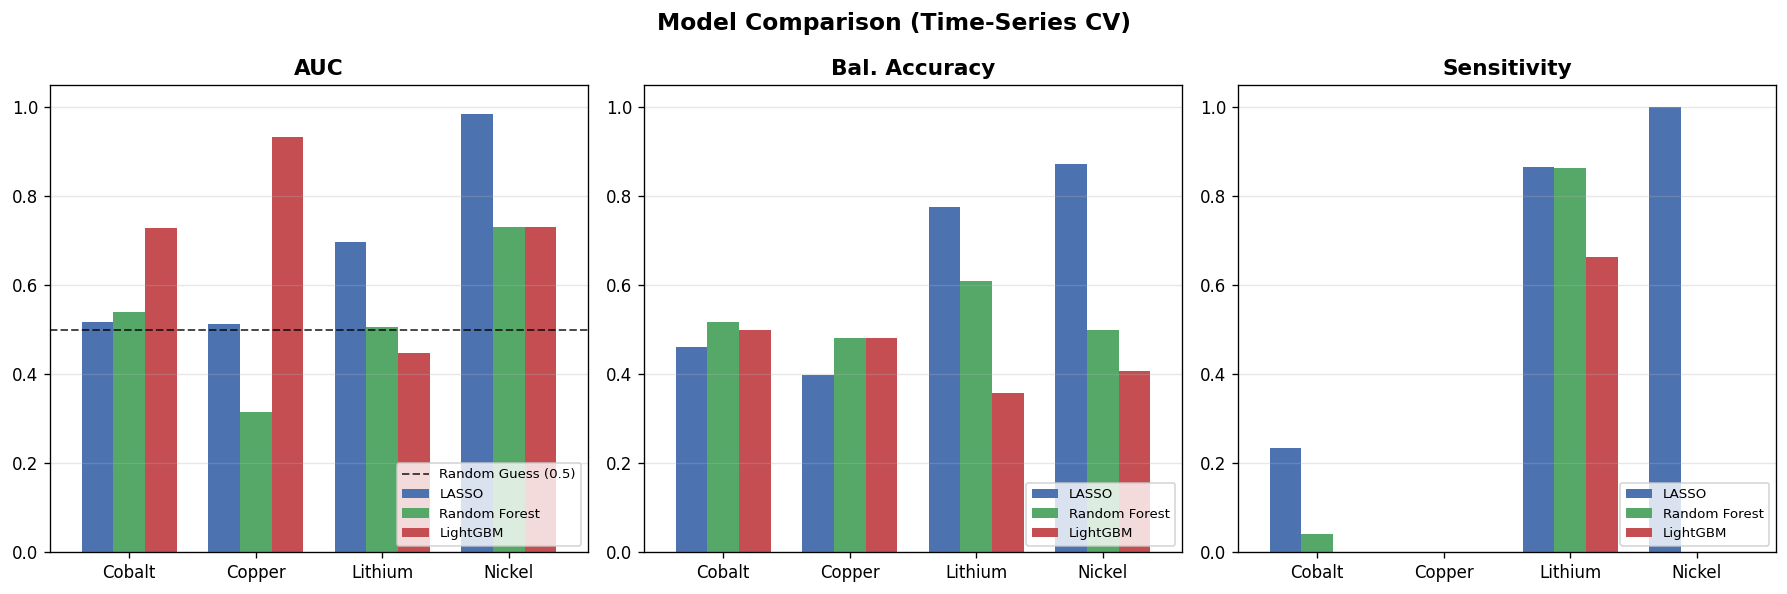

In [9]:
# Assemble results table
rows = []
for metal in metal_configs:
    for mname, res_dict in [('LASSO', results_lasso),
                             ('Random Forest', results_rf),
                             ('LightGBM', results_lgbm)]:
        if metal in res_dict:
            row = {'Metal': metal, 'Model': mname}
            row.update(res_dict[metal])
            rows.append(row)

df_results = pd.DataFrame(rows)
display_cols = ['Metal', 'Model', 'Bal. Accuracy', 'Sensitivity',
                'Specificity', 'Precision', 'AUC', 'Bubbles']
print(df_results[display_cols].to_string(index=False))
print()

# Bar chart comparison
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
colors = {'LASSO': '#4C72B0', 'Random Forest': '#55A868', 'LightGBM': '#C44E52'}

for i, metric in enumerate(['AUC', 'Bal. Accuracy', 'Sensitivity']):
    ax = axes[i]
    pivot = df_results.pivot(index='Metal', columns='Model', values=metric)
    pivot = pivot[['LASSO', 'Random Forest', 'LightGBM']]
    pivot.plot(kind='bar', ax=ax, rot=0,
              color=[colors[c] for c in pivot.columns], width=0.75)
    ax.set_title(metric, fontsize=13, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylim(0, 1.05)
    ax.legend(fontsize=8, loc='lower right')
    ax.grid(axis='y', alpha=0.3)
    
    # Mark random guess baseline
    if metric == 'AUC':
        ax.axhline(0.5, color='black', lw=1.2, ls='--', alpha=0.7, label='Random Guess (0.5)')
        ax.legend(fontsize=8, loc='lower right')

plt.suptitle('Model Comparison (Time-Series CV)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/model_comparison.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

In [10]:
# Best hyperparameters found per model
print('Best Hyperparameters')
print('=' * 55)
for metal in metal_configs:
    print(f'\n{metal}:')
    if metal in lasso_best_params:
        print(f'  LASSO:    C={lasso_best_params[metal]["C"]}')
    if metal in rf_best_params:
        print(f'  RF:       {rf_best_params[metal]}')
    if metal in lgbm_best_params:
        print(f'  LightGBM: {lgbm_best_params[metal]}')

Best Hyperparameters

Cobalt:
  LASSO:    C=0.1
  RF:       {'max_depth': 15, 'min_samples_leaf': 25, 'max_features': 'log2'}
  LightGBM: {'num_leaves': 31, 'max_depth': -1, 'learning_rate': 0.05, 'lambda_l1': 0.1, 'lambda_l2': 5.0, 'min_data_in_leaf': 5}

Lithium:
  LASSO:    C=0.001
  RF:       {'max_depth': 5, 'min_samples_leaf': 1, 'max_features': 0.3}
  LightGBM: {'num_leaves': 63, 'max_depth': -1, 'learning_rate': 0.01, 'lambda_l1': 0, 'lambda_l2': 0, 'min_data_in_leaf': 5}

Nickel:
  LASSO:    C=0.1
  RF:       {'max_depth': 10, 'min_samples_leaf': 5, 'max_features': 0.3}
  LightGBM: {'num_leaves': 15, 'max_depth': 5, 'learning_rate': 0.1, 'lambda_l1': 5.0, 'lambda_l2': 5.0, 'min_data_in_leaf': 5}

Copper:
  LASSO:    C=10.0
  RF:       {'max_depth': None, 'min_samples_leaf': 10, 'max_features': 0.3}
  LightGBM: {'num_leaves': 15, 'max_depth': 10, 'learning_rate': 0.1, 'lambda_l1': 0.1, 'lambda_l2': 5.0, 'min_data_in_leaf': 50}


## 9. ROC Curves

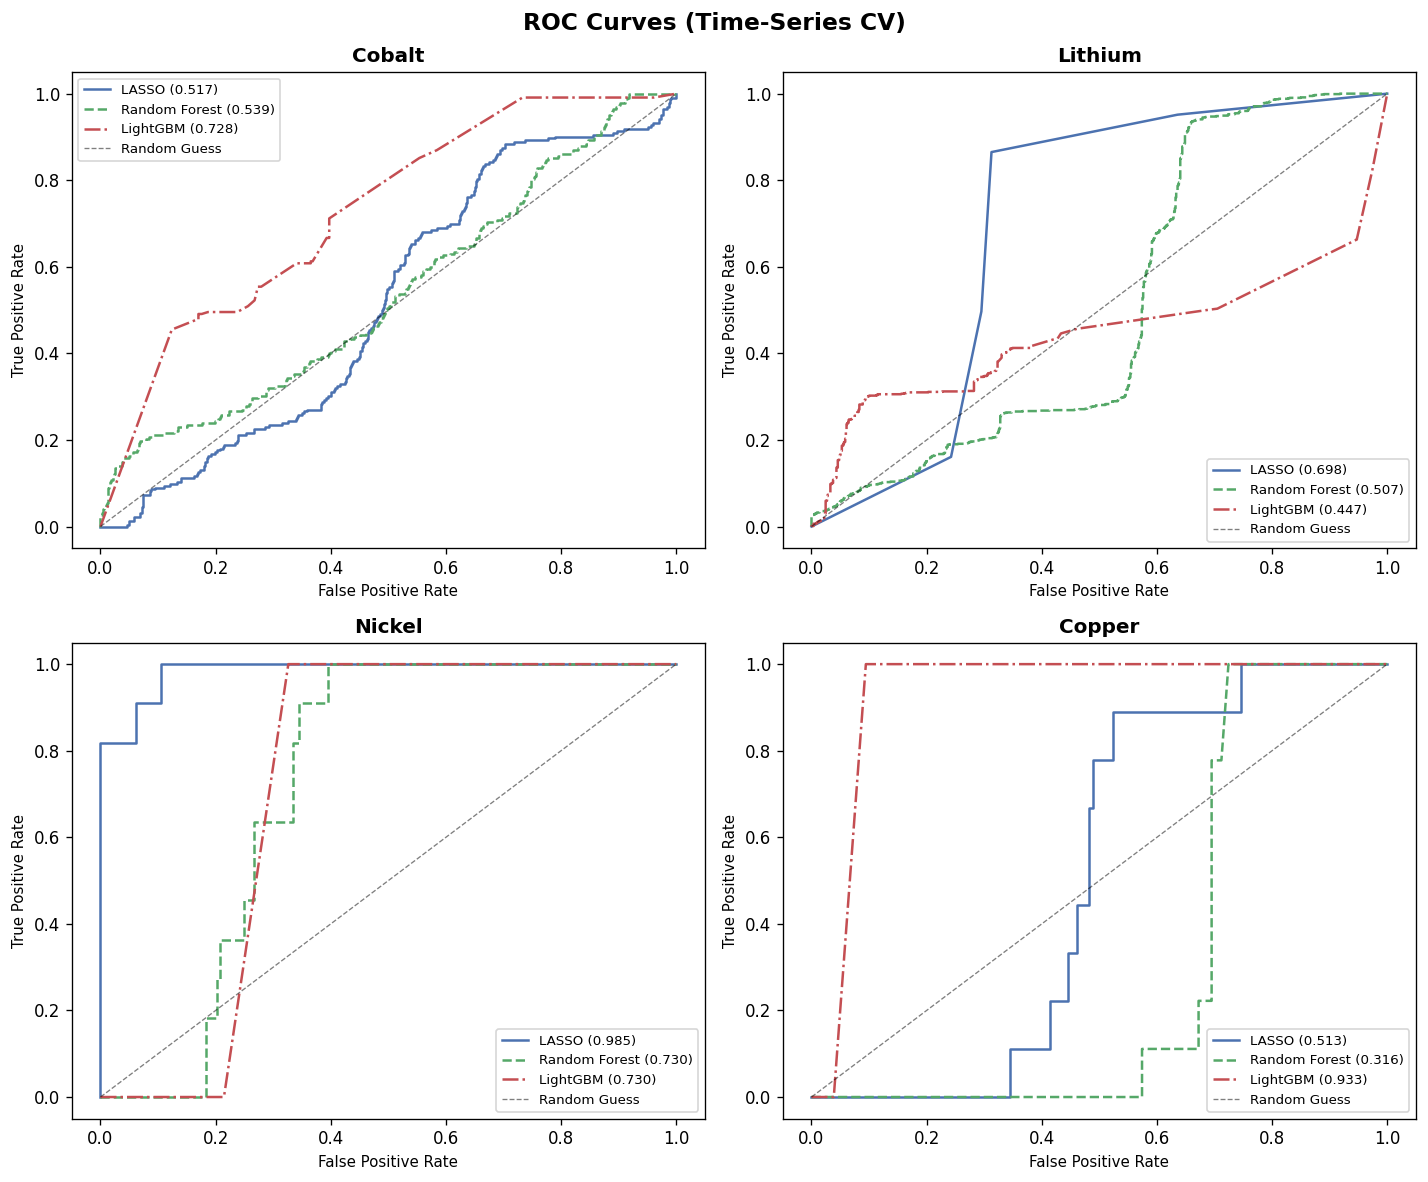

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
colors = {'LASSO': '#4C72B0', 'Random Forest': '#55A868', 'LightGBM': '#C44E52'}
styles = {'LASSO': '-', 'Random Forest': '--', 'LightGBM': '-.'}

for idx, metal in enumerate(metal_configs):
    ax = axes.flat[idx]
    for mname in ['LASSO', 'Random Forest', 'LightGBM']:
        key = (metal, mname)
        if key in cv_preds:
            yt, yp = cv_preds[key]
            fpr, tpr, _ = roc_curve(yt, yp)
            auc_val = roc_auc_score(yt, yp)
            ax.plot(fpr, tpr, color=colors[mname], ls=styles[mname], lw=1.5,
                    label='{} ({:.3f})'.format(mname, auc_val))
    ax.plot([0, 1], [0, 1], 'k--', lw=0.8, alpha=0.5, label='Random Guess')
    ax.set_title(metal, fontsize=12, fontweight='bold')
    ax.legend(fontsize=8)
    ax.set_xlabel('False Positive Rate', fontsize=9)
    ax.set_ylabel('True Positive Rate', fontsize=9)

plt.suptitle('ROC Curves (Time-Series CV)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/roc_curves.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

## 10. Feature Importance

- **LightGBM:** SHAP values (TreeSHAP, exact for tree models)
- **LASSO:** Non-zero standardized coefficients
- **Random Forest:** Gini importance (mean decrease in impurity)

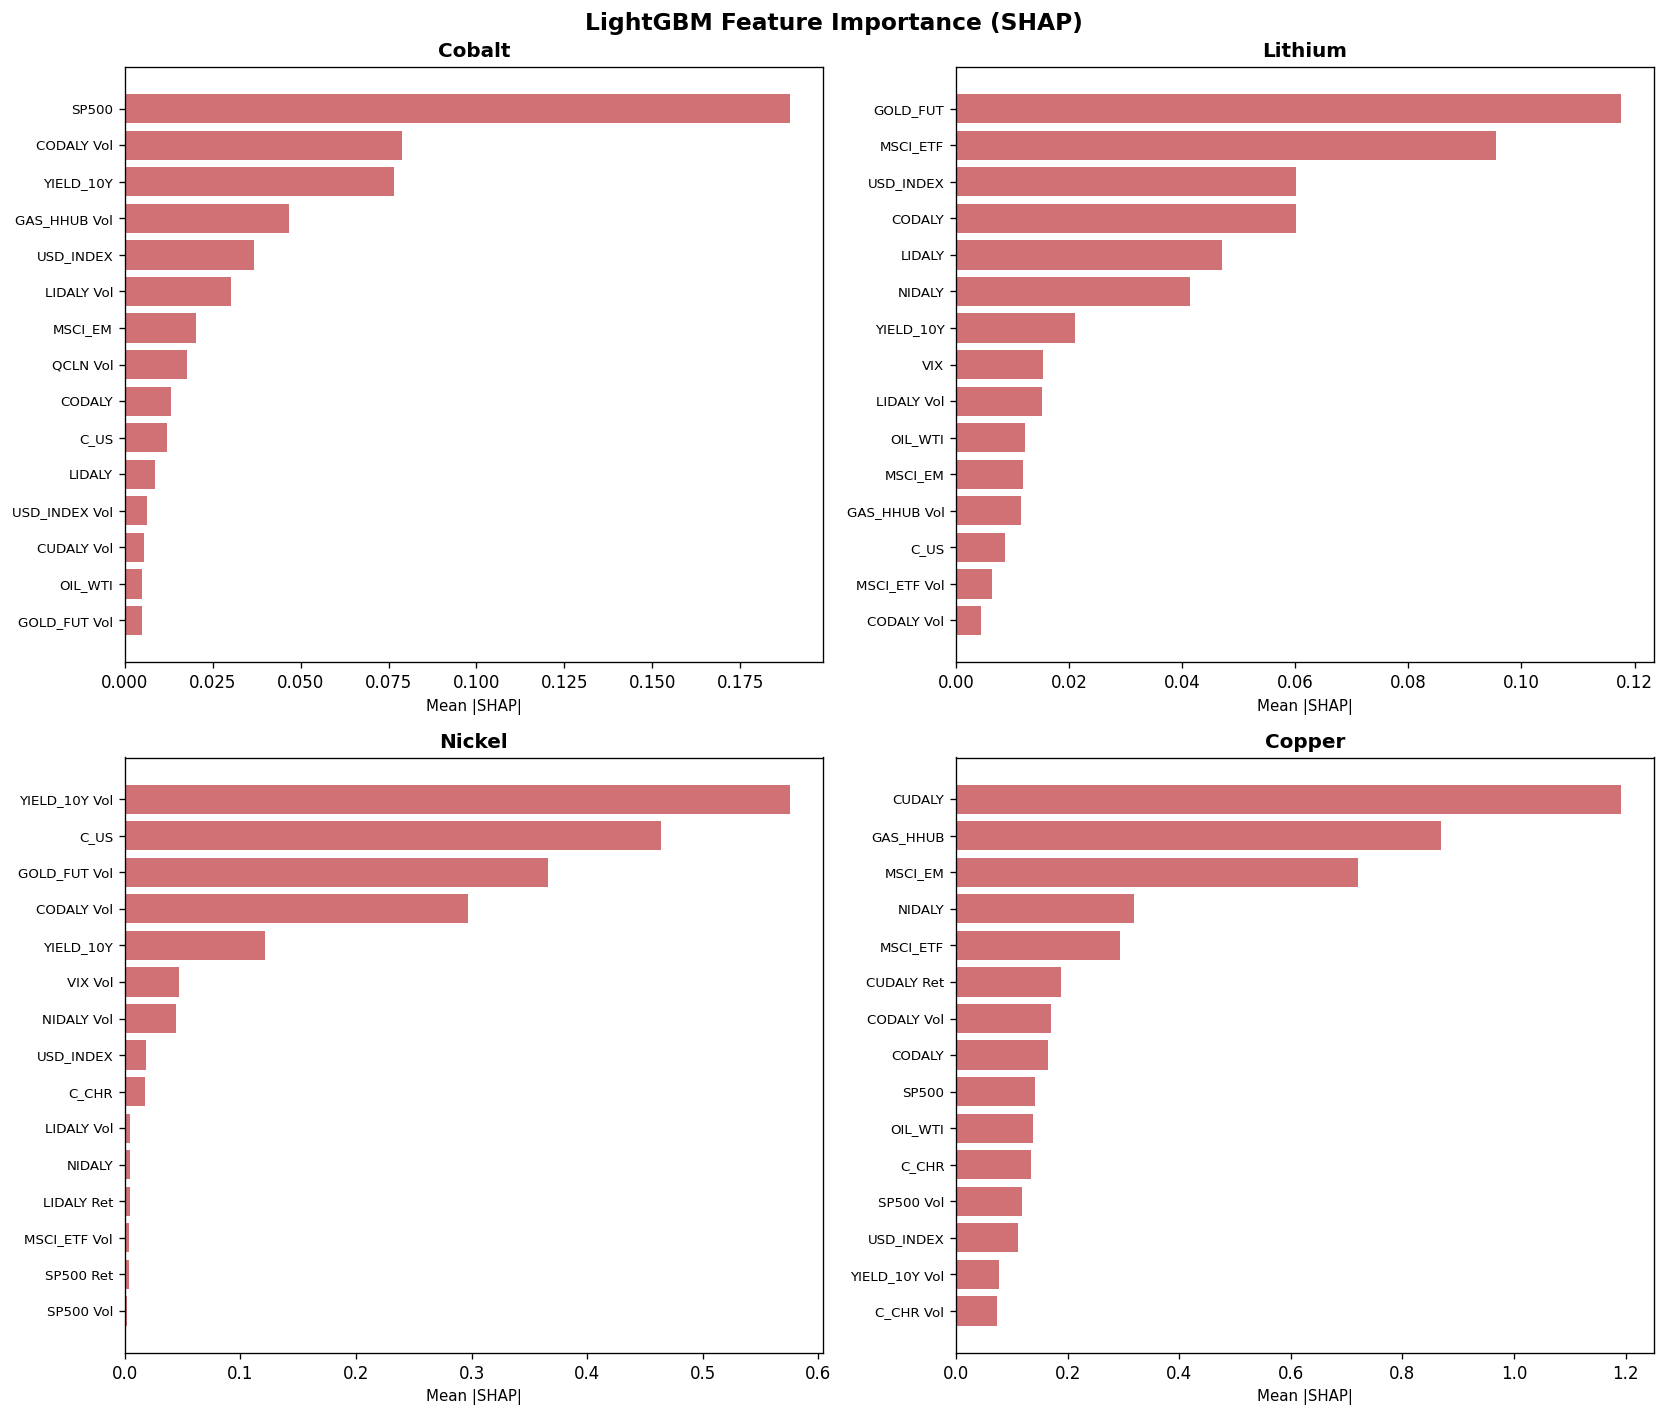

In [12]:
def clean_name(s):
    '''Shorten feature names for plots.'''
    return (s.replace('_Lag1', '').replace('_Level', '')
             .replace('_Ret', ' Ret').replace('_Vol', ' Vol')
             .replace('_BD', ' Bubble'))

# --- LightGBM SHAP ---
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
for idx, (metal, col) in enumerate(metal_configs.items()):
    ax = axes.flat[idx]
    if metal not in lgbm_models:
        ax.set_visible(False)
        continue
    info = lgbm_models[metal]
    explainer = shap.TreeExplainer(info['model'])
    np.random.seed(42)
    sample_idx = np.random.choice(len(info['X']), min(500, len(info['X'])), replace=False)
    sv = explainer.shap_values(info['X'][sample_idx])
    if isinstance(sv, list):
        sv = sv[1]

    mean_abs = np.mean(np.abs(sv), axis=0)
    top_k = 15
    top_idx = np.argsort(mean_abs)[-top_k:]
    names = [clean_name(info['features'][i]) for i in top_idx]

    ax.barh(range(top_k), mean_abs[top_idx], color='#C44E52', alpha=0.8)
    ax.set_yticks(range(top_k))
    ax.set_yticklabels(names, fontsize=8)
    ax.set_title(metal, fontsize=12, fontweight='bold')
    ax.set_xlabel('Mean |SHAP|', fontsize=9)

plt.suptitle('LightGBM Feature Importance (SHAP)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/shap_lgbm.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

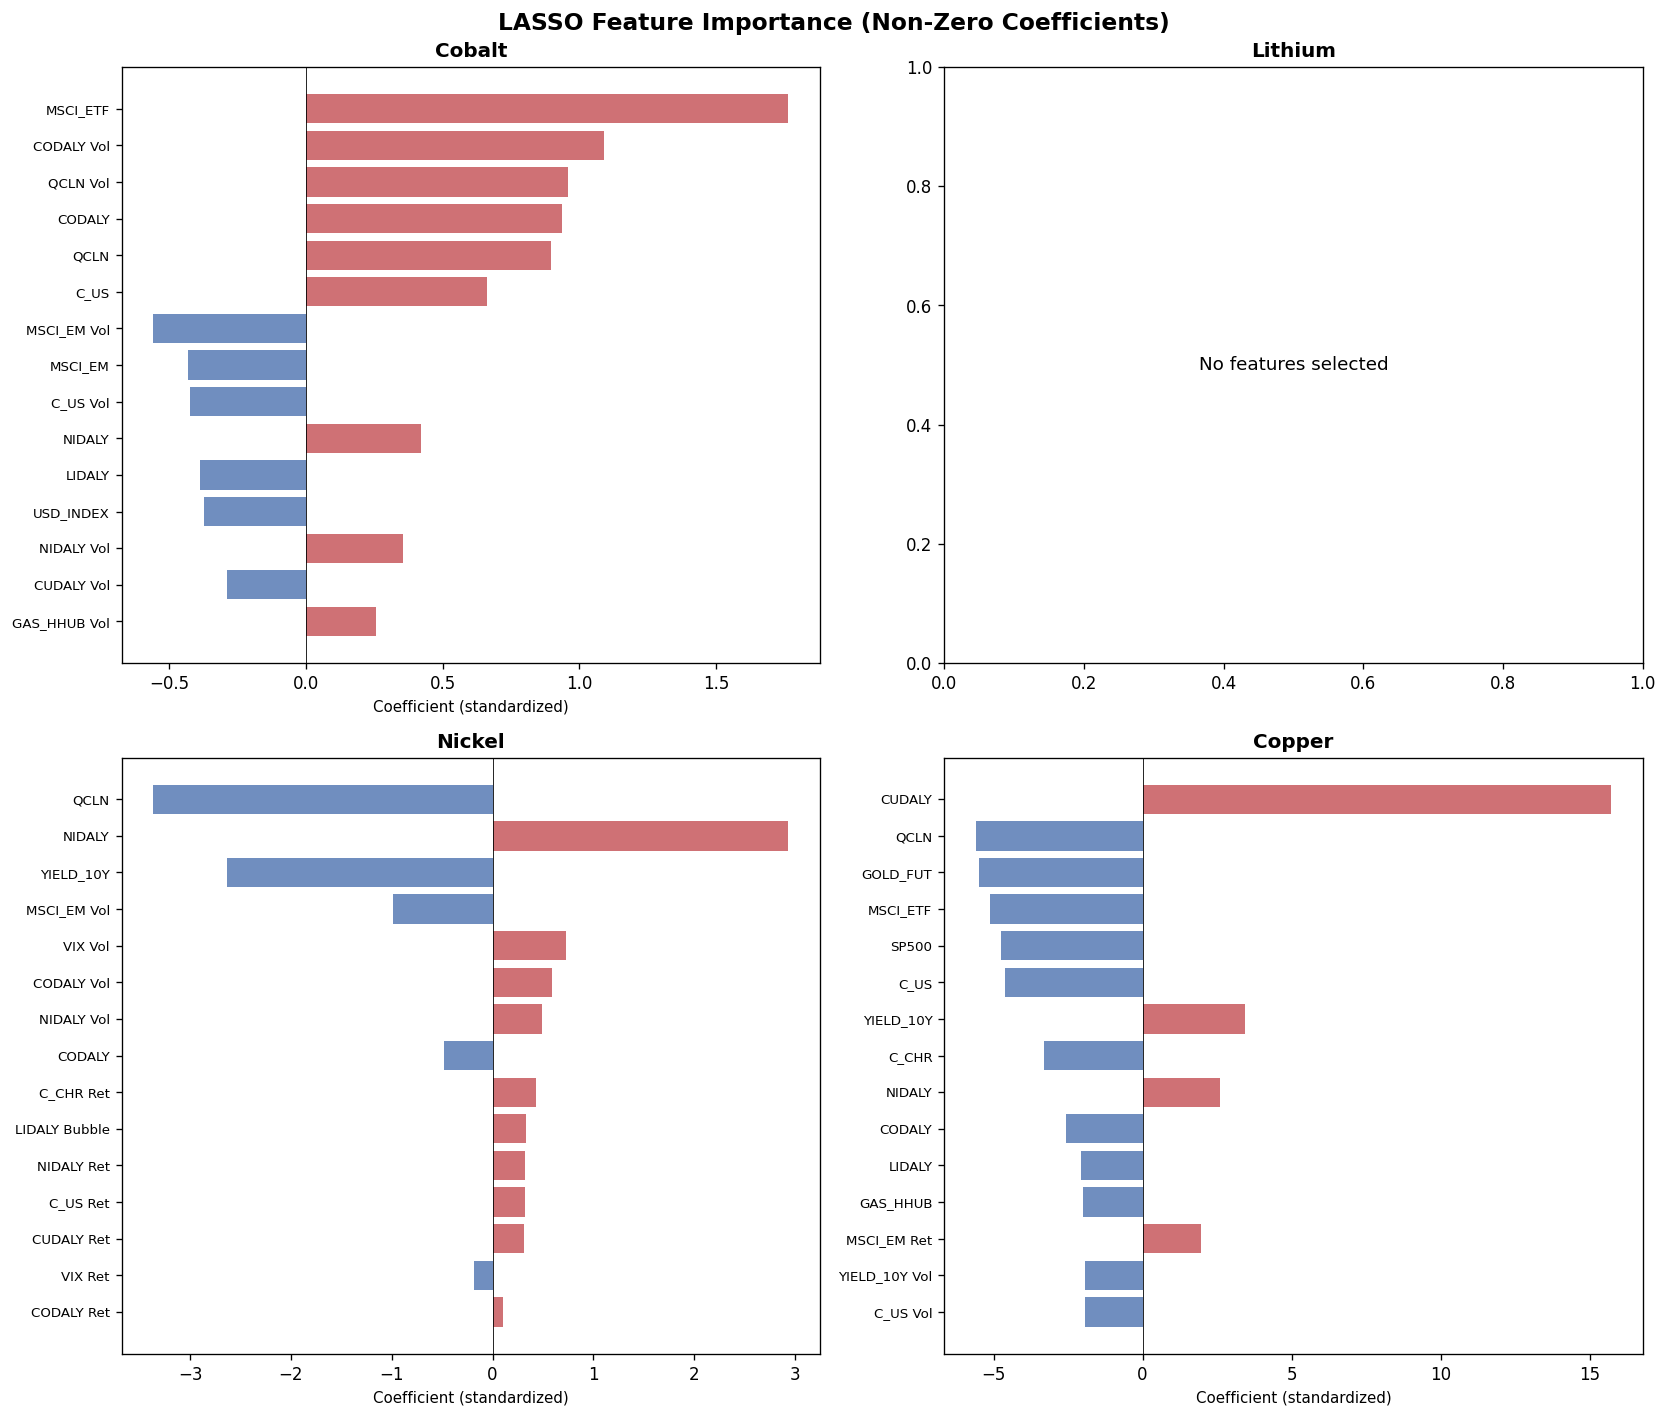

In [13]:
# --- LASSO Coefficients ---
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
for idx, (metal, col) in enumerate(metal_configs.items()):
    ax = axes.flat[idx]
    if metal not in lasso_models:
        ax.set_visible(False)
        continue
    info = lasso_models[metal]
    coefs = info['model'].coef_[0]
    feats = info['features']

    nz_mask = coefs != 0
    if nz_mask.sum() == 0:
        ax.text(0.5, 0.5, 'No features selected', ha='center', va='center',
                transform=ax.transAxes, fontsize=11)
        ax.set_title(metal, fontsize=12, fontweight='bold')
        continue

    nz_coefs = coefs[nz_mask]
    nz_names = [clean_name(feats[i]) for i in range(len(feats)) if nz_mask[i]]

    top_k = min(15, len(nz_coefs))
    order = np.argsort(np.abs(nz_coefs))[-top_k:]
    bar_colors = ['#C44E52' if nz_coefs[j] > 0 else '#4C72B0' for j in order]

    ax.barh(range(top_k), nz_coefs[order], color=bar_colors, alpha=0.8)
    ax.set_yticks(range(top_k))
    ax.set_yticklabels([nz_names[j] for j in order], fontsize=8)
    ax.set_title(metal, fontsize=12, fontweight='bold')
    ax.set_xlabel('Coefficient (standardized)', fontsize=9)
    ax.axvline(0, color='black', lw=0.5)

plt.suptitle('LASSO Feature Importance (Non-Zero Coefficients)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/lasso_coefficients.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

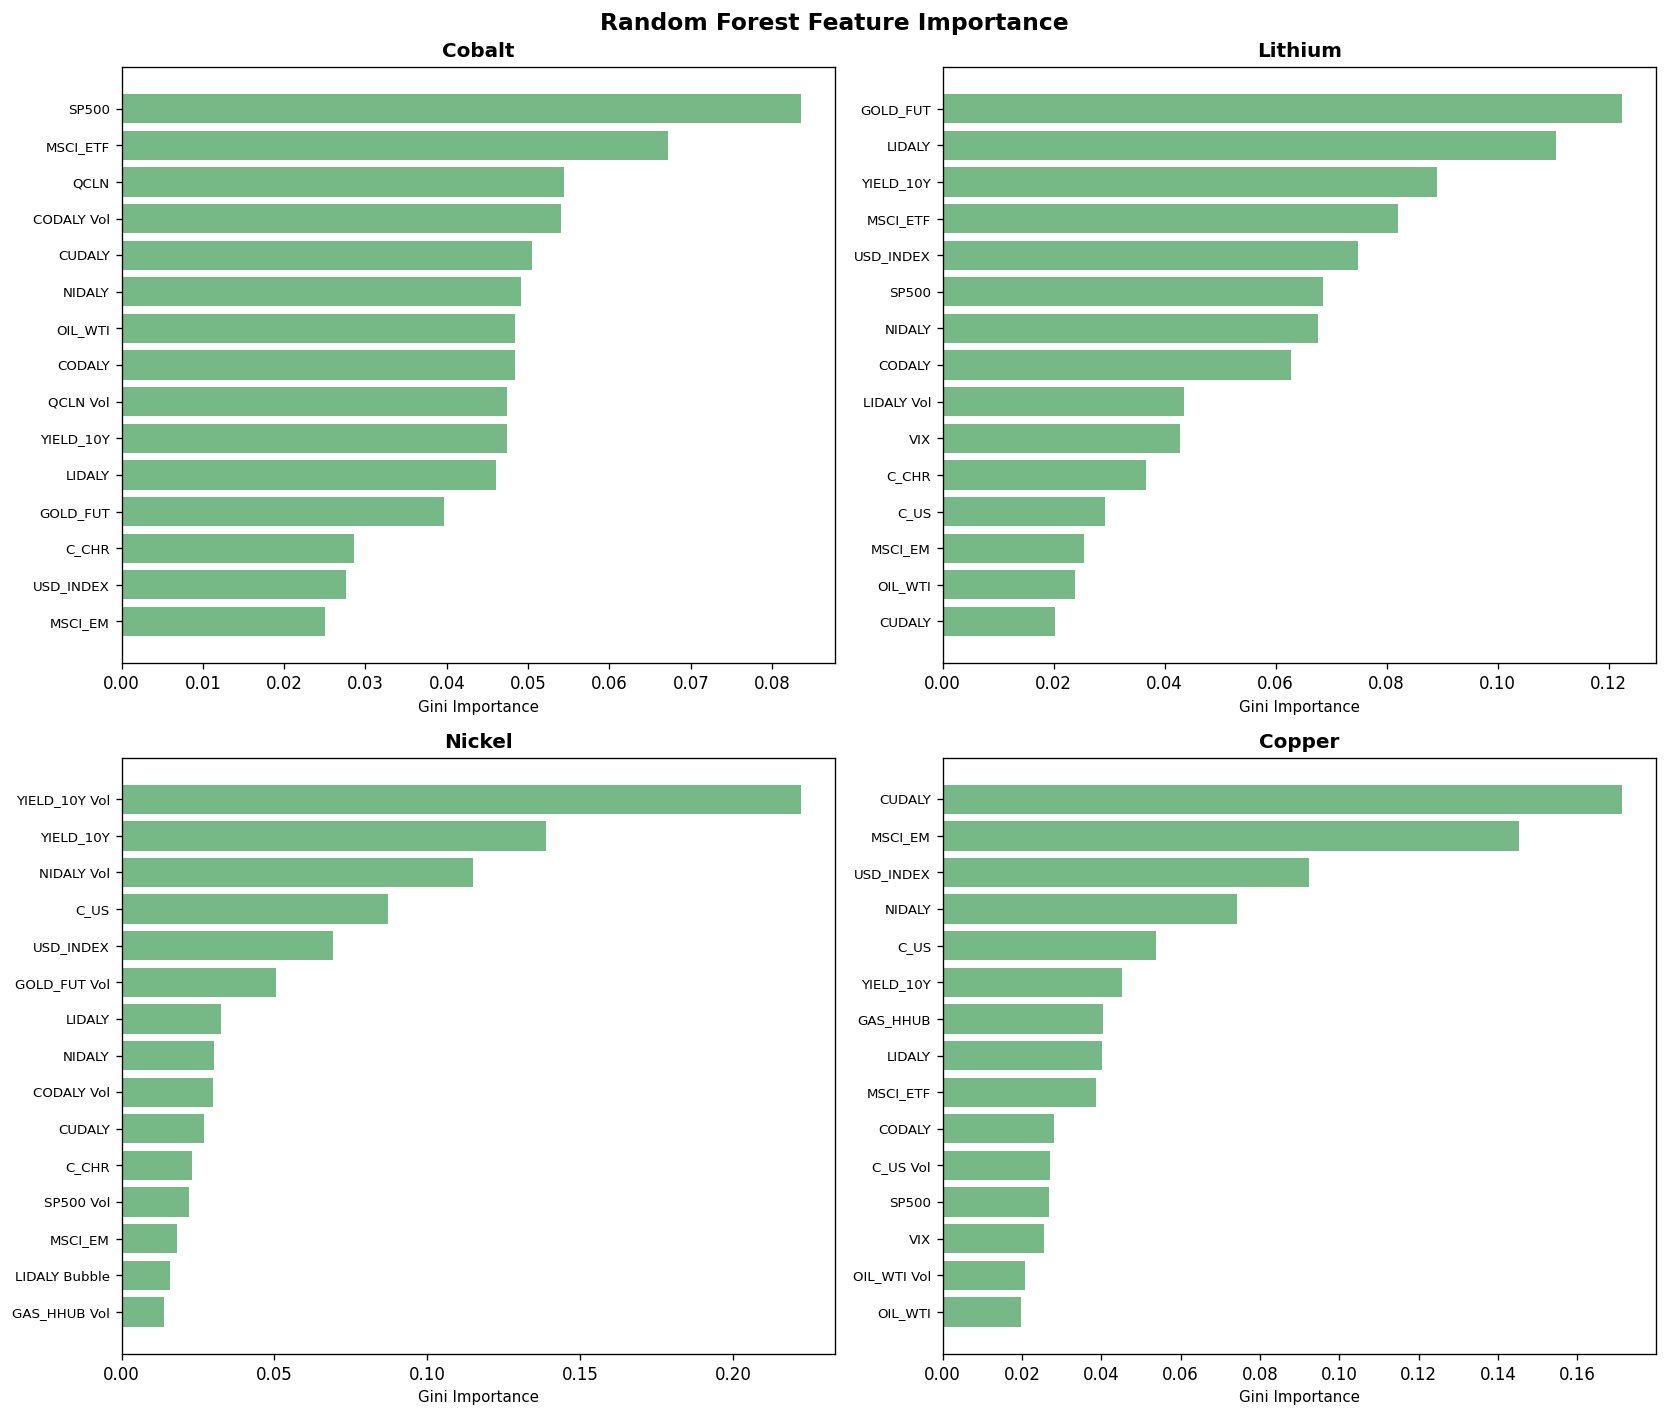

In [14]:
# --- Random Forest Gini Importance ---
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
for idx, (metal, col) in enumerate(metal_configs.items()):
    ax = axes.flat[idx]
    if metal not in rf_models:
        ax.set_visible(False)
        continue
    info = rf_models[metal]
    imp = info['model'].feature_importances_
    top_k = 15
    top_idx = np.argsort(imp)[-top_k:]
    names = [clean_name(info['features'][i]) for i in top_idx]

    ax.barh(range(top_k), imp[top_idx], color='#55A868', alpha=0.8)
    ax.set_yticks(range(top_k))
    ax.set_yticklabels(names, fontsize=8)
    ax.set_title(metal, fontsize=12, fontweight='bold')
    ax.set_xlabel('Gini Importance', fontsize=9)

plt.suptitle('Random Forest Feature Importance', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/rf_importance.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

## Summary

| Correction | Status |
|---|---|
| Time-series CV (expanding window) | ✅ No future leakage in evaluation |
| Consistent class imbalance handling | ✅ Balanced weights for all models |
| Same feature set across models | ✅ Fair comparison |
| Early stopping for LightGBM | ✅ Temporal validation set per fold |
| **Hyperparameter tuning** | ✅ Grid search (LASSO) + randomized search (RF, LightGBM) |
| Bubble labels = full-sample GSADF | Kept as ground truth (by design) |

**Tuning approach:** All hyperparameters searched using the **same time-series CV** (expanding window)
to prevent overfitting the tuning process. Scoring metric: **AUC**.

**Outputs saved to `outputs/` folder.**

## 11. Momentum-Filtered GSADF Labels (Updated Baseline)

The R pipeline (`metals30_data_prep.R`) was updated with a **momentum filter**: within any
GSADF-detected bubble episode a day is only labelled `1` if the metal price is **strictly
higher than 10 trading days earlier** (`growth = price[t] − price[t−10] > 0`).
This removes detections that fire while the price is already declining — keeping only
the explosive upward phase of each episode.

**Key differences vs the original GSADF labels:**

| Property | Original (`df_master.csv`) | Momentum-filtered (`df_final_dataset201711.csv`) |
|---|---|---|
| Start date | ≈ 2017-01-03 | **2017-11-01** (later) |
| Bubble criterion | GSADF significant | GSADF significant **and** 10-day price growth > 0 |
| Expected prevalence | Higher | Lower (declining phases removed) |
| Macro/market columns | ✅ Included | ❌ Price + BD only → must join from `df_master` |

> **Note on the shorter sample:** The R script that generates `df_final_dataset201711.csv`
> applies a 10-day look-back before the first bubble check, so the effective start date
> is 2017-11-01 instead of the dataset's earliest available observation.
> After joining with `df_master`, only dates present in **both** files are retained.

In [ ]:
# ── Load momentum-filtered GSADF dataset ────────────────────────────────────
MOM_PATH = '../R/data_R/df_final_dataset201711.csv'

df_mom_raw = pd.read_csv(MOM_PATH, sep=';', decimal=',', index_col=0)
df_mom_raw['Date'] = pd.to_datetime(df_mom_raw['Date'])
df_mom_raw = df_mom_raw.sort_values('Date').reset_index(drop=True)

print('Momentum-filtered file:')
print(f'  Columns : {list(df_mom_raw.columns)}')
print(f'  Period  : {df_mom_raw["Date"].min().date()}  →  {df_mom_raw["Date"].max().date()}')
print(f'  Rows    : {len(df_mom_raw)}')
print()

# ── Join macro/market features from df_master (inner join on Date) ───────────
# df_master already defined in section 1.  Drop its original _BD columns;
# replace them with the momentum-filtered ones from df_mom_raw.
bd_cols_orig = [c for c in df_master.columns if c.endswith('_BD')]
df_base = df_master.drop(columns=bd_cols_orig)

bd_cols_mom = [c for c in df_mom_raw.columns if c.endswith('_BD')]
df_mom = df_base.merge(df_mom_raw[['Date'] + bd_cols_mom], on='Date', how='inner')
df_mom = df_mom.sort_values('Date').reset_index(drop=True)

print(f'Merged dataset (inner join):')
print(f'  Period : {df_mom["Date"].min().date()}  →  {df_mom["Date"].max().date()}')
print(f'  Rows   : {len(df_mom)}  (original df_master had {len(df_master)})')
print()

# ── Bubble prevalence comparison ─────────────────────────────────────────────
# Reference: original GSADF labels over the SAME restricted date window
df_orig_window = df_master[df_master['Date'] >= df_mom['Date'].min()].copy()

print(f'{"Metal":10s}  {"Orig GSADF days":>15s}  {"Orig GSADF %":>12s}  {"Mom-filtered days":>17s}  {"Mom %":>6s}')
print('-' * 70)
for metal, col in metal_configs.items():
    bd = col + '_BD'
    n_orig = int(df_orig_window[bd].sum())
    pct_orig = 100 * n_orig / len(df_orig_window)
    n_mom = int(df_mom[bd].sum())
    pct_mom = 100 * n_mom / len(df_mom)
    print(f'{metal:10s}  {n_orig:15d}  {pct_orig:11.1f}%  {n_mom:17d}  {pct_mom:5.1f}%')


In [ ]:
# ── Bubble period timelines — momentum-filtered labels ───────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 7))

for idx, (metal, col) in enumerate(metal_configs.items()):
    ax    = axes.flat[idx]
    bd    = col + '_BD'
    dates = df_mom['Date']
    ax.plot(dates, df_mom[col], color='black', lw=0.7)

    bub = df_mom[bd].values
    in_b = False
    for i in range(len(bub)):
        if bub[i] == 1 and not in_b:
            start = dates.iloc[i]; in_b = True
        elif (bub[i] == 0 or i == len(bub) - 1) and in_b:
            ax.axvspan(start, dates.iloc[i], color='darkorange', alpha=0.3)
            in_b = False

    n_b = int(bub.sum())
    ax.set_title(f'{metal}  —  momentum-filtered bubbles: {n_b} days ({100*n_b/len(df_mom):.1f}%)',
                 fontsize=11, fontweight='bold')
    ax.tick_params(labelsize=8)
    ax.set_ylabel('Price', fontsize=9)

plt.suptitle('Metal Prices — Momentum-Filtered GSADF Bubble Periods (orange)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/bubble_timelines_momentum.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()


In [ ]:
# ── LASSO — momentum-filtered labels ────────────────────────────────────────
results_lasso_mom = {}
lasso_models_mom  = {}
lasso_best_params_mom = {}
cv_preds_mom = {}

C_grid = [0.001, 0.01, 0.1, 1.0, 10.0]

print('LASSO — Momentum-Filtered GSADF Labels')
print('=' * 55)

for metal, col in metal_configs.items():
    df_ml = prepare_ml_data(col, df_mom)
    feats = [c for c in df_ml.columns if c not in ['Date', 'Target']]
    X, y  = df_ml[feats].values, df_ml['Target'].values

    if y.sum() < 10:
        print(f'  {metal}: skipped — only {int(y.sum())} bubble days')
        continue

    best_auc, best_C = -1, 1.0
    for C_val in C_grid:
        def make_lasso_c(c=C_val):
            return LogisticRegression(penalty='l1', solver='saga', C=c,
                                      class_weight='balanced', max_iter=10000, random_state=42)
        try:
            preds_c, true_c = run_timeseries_cv(X, y, make_lasso_c, n_splits=5, scale=True)
            auc_c = roc_auc_score(true_c, preds_c) if len(np.unique(true_c)) > 1 else 0.5
            if auc_c > best_auc:
                best_auc, best_C = auc_c, C_val
        except Exception:
            continue

    def make_lasso_best(c=best_C):
        return LogisticRegression(penalty='l1', solver='saga', C=c,
                                  class_weight='balanced', max_iter=10000, random_state=42)

    preds, true = run_timeseries_cv(X, y, make_lasso_best, n_splits=5, scale=True)
    if len(preds) == 0 or len(np.unique(true)) < 2:
        print(f'  {metal}: no valid CV fold'); continue

    metrics = compute_metrics(true, preds)
    results_lasso_mom[metal]     = metrics
    lasso_best_params_mom[metal] = {'C': best_C}
    cv_preds_mom[(metal, 'LASSO')] = (true, preds)

    sc = StandardScaler()
    full = make_lasso_best()
    full.fit(sc.fit_transform(X), y)
    lasso_models_mom[metal] = {'model': full, 'features': feats, 'scaler': sc}
    n_nz = int(np.sum(full.coef_[0] != 0))
    print('  {}: AUC={:.3f}  Bal.Acc={:.3f}  Bubbles={}  (C={}, non-zero: {})'.format(
        metal, metrics['AUC'], metrics['Bal. Accuracy'], metrics['Bubbles'], best_C, n_nz))


In [ ]:
# ── Random Forest — momentum-filtered labels ─────────────────────────────────
from itertools import product
import random

results_rf_mom     = {}
rf_models_mom      = {}
rf_best_params_mom = {}

rf_param_grid = {
    'max_depth':        [5, 10, 15, 20, None],
    'min_samples_leaf': [1, 5, 10, 25],
    'max_features':     ['sqrt', 'log2', 0.3],
}
all_combos   = [dict(zip(rf_param_grid.keys(), v)) for v in product(*rf_param_grid.values())]
random.seed(42)
rf_candidates = random.sample(all_combos, min(20, len(all_combos)))

print(f'Random Forest — Momentum-Filtered GSADF ({len(rf_candidates)} configs)')
print('=' * 55)

for metal, col in metal_configs.items():
    df_ml = prepare_ml_data(col, df_mom)
    feats = [c for c in df_ml.columns if c not in ['Date', 'Target']]
    X, y  = df_ml[feats].values, df_ml['Target'].values

    if y.sum() < 10:
        print(f'  {metal}: skipped — only {int(y.sum())} bubble days'); continue

    best_auc, best_params = -1, {}
    for params in rf_candidates:
        def make_rf_p(p=params):
            return RandomForestClassifier(n_estimators=500, class_weight='balanced',
                                          random_state=42, n_jobs=-1, **p)
        try:
            preds_p, true_p = run_timeseries_cv(X, y, make_rf_p, n_splits=5)
            auc_p = roc_auc_score(true_p, preds_p) if len(np.unique(true_p)) > 1 else 0.5
            if auc_p > best_auc:
                best_auc, best_params = auc_p, params
        except Exception:
            continue

    def make_rf_best(p=best_params):
        return RandomForestClassifier(n_estimators=500, class_weight='balanced',
                                      random_state=42, n_jobs=-1, **p)

    preds, true = run_timeseries_cv(X, y, make_rf_best, n_splits=5)
    if len(preds) == 0 or len(np.unique(true)) < 2:
        print(f'  {metal}: no valid CV fold'); continue

    metrics = compute_metrics(true, preds)
    results_rf_mom[metal]     = metrics
    rf_best_params_mom[metal] = best_params
    cv_preds_mom[(metal, 'Random Forest')] = (true, preds)

    full = make_rf_best()
    full.fit(X, y)
    rf_models_mom[metal] = {'model': full, 'features': feats, 'X': X, 'y': y}

    print('  {}: AUC={:.3f}  Bal.Acc={:.3f}  Bubbles={}  {}'.format(
        metal, metrics['AUC'], metrics['Bal. Accuracy'], metrics['Bubbles'],
        {k: v for k, v in best_params.items()}))


In [ ]:
# ── LightGBM — momentum-filtered labels ──────────────────────────────────────
results_lgbm_mom     = {}
lgbm_models_mom      = {}
lgbm_best_params_mom = {}

lgb_base = {
    'objective': 'binary', 'metric': 'auc', 'is_unbalance': True,
    'feature_fraction': 0.8, 'bagging_fraction': 0.8, 'bagging_freq': 5,
    'verbosity': -1, 'seed': 42,
}
lgb_tune_grid = {
    'num_leaves':       [15, 31, 63],
    'max_depth':        [-1, 5, 10],
    'learning_rate':    [0.01, 0.05, 0.1],
    'lambda_l1':        [0, 0.1, 1.0, 5.0],
    'lambda_l2':        [0, 0.1, 1.0, 5.0],
    'min_data_in_leaf': [5, 20, 50],
}
all_lgb = [dict(zip(lgb_tune_grid.keys(), v)) for v in product(*lgb_tune_grid.values())]
random.seed(42)
lgb_candidates = random.sample(all_lgb, min(30, len(all_lgb)))

print(f'LightGBM — Momentum-Filtered GSADF ({len(lgb_candidates)} configs)')
print('=' * 55)

for metal, col in metal_configs.items():
    df_ml = prepare_ml_data(col, df_mom)
    feats = [c for c in df_ml.columns if c not in ['Date', 'Target']]
    X, y  = df_ml[feats].values, df_ml['Target'].values

    if y.sum() < 10:
        print(f'  {metal}: skipped — only {int(y.sum())} bubble days'); continue

    best_auc, best_hp = -1, {}
    for hp in lgb_candidates:
        params = {**lgb_base, **hp}
        try:
            preds_hp, true_hp, _ = run_lgbm_cv(X, y, params, n_splits=5)
            if len(true_hp) == 0 or len(np.unique(true_hp)) < 2:
                continue
            auc_hp = roc_auc_score(true_hp, preds_hp)
            if auc_hp > best_auc:
                best_auc, best_hp = auc_hp, hp
        except Exception:
            continue

    best_params = {**lgb_base, **best_hp}
    preds_arr, true_arr, best_iters = run_lgbm_cv(X, y, best_params, n_splits=5)

    if len(preds_arr) == 0 or len(np.unique(true_arr)) < 2:
        print(f'  {metal}: no valid CV fold'); continue

    metrics = compute_metrics(true_arr, preds_arr)
    results_lgbm_mom[metal]     = metrics
    lgbm_best_params_mom[metal] = best_hp
    cv_preds_mom[(metal, 'LightGBM')] = (true_arr, preds_arr)

    avg_iter = int(np.mean(best_iters)) if best_iters else 10
    d_full   = lgb.Dataset(X, y)
    bst_full = lgb.train(best_params, d_full, num_boost_round=max(avg_iter, 10))
    lgbm_models_mom[metal] = {'model': bst_full, 'features': feats, 'X': X, 'y': y}

    print('  {}: AUC={:.3f}  Bal.Acc={:.3f}  Bubbles={}  (iters: {})'.format(
        metal, metrics['AUC'], metrics['Bal. Accuracy'], metrics['Bubbles'], avg_iter))
    print('        best: lr={}, leaves={}, depth={}, l1={}, l2={}, min_leaf={}'.format(
        best_hp.get('learning_rate'), best_hp.get('num_leaves'), best_hp.get('max_depth'),
        best_hp.get('lambda_l1'), best_hp.get('lambda_l2'), best_hp.get('min_data_in_leaf')))


In [ ]:
# ── Results table + bar chart — momentum-filtered labels ─────────────────────
rows_mom = []
for metal in metal_configs:
    for mname, res_dict in [('LASSO', results_lasso_mom),
                             ('Random Forest', results_rf_mom),
                             ('LightGBM', results_lgbm_mom)]:
        if metal in res_dict:
            row = {'Metal': metal, 'Model': mname}
            row.update(res_dict[metal])
            rows_mom.append(row)

if not rows_mom:
    print('No results — all metals skipped (insufficient bubble days).')
else:
    df_res_mom   = pd.DataFrame(rows_mom)
    display_cols = ['Metal', 'Model', 'Bal. Accuracy', 'Sensitivity',
                    'Specificity', 'Precision', 'AUC', 'Bubbles']
    print('Results — Momentum-Filtered GSADF Labels')
    print(df_res_mom[display_cols].to_string(index=False))
    print()

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    colors = {'LASSO': '#4C72B0', 'Random Forest': '#55A868', 'LightGBM': '#C44E52'}

    for i, metric in enumerate(['AUC', 'Bal. Accuracy', 'Sensitivity']):
        ax    = axes[i]
        pivot = df_res_mom.pivot(index='Metal', columns='Model', values=metric)
        pivot = pivot[[m for m in ['LASSO', 'Random Forest', 'LightGBM'] if m in pivot.columns]]
        pivot.plot(kind='bar', ax=ax, rot=0,
                   color=[colors[c] for c in pivot.columns], width=0.75)
        ax.set_title(metric, fontsize=13, fontweight='bold')
        ax.set_xlabel('')
        ax.set_ylim(0, 1.05)
        ax.legend(fontsize=8, loc='lower right')
        ax.grid(axis='y', alpha=0.3)
        if metric == 'AUC':
            ax.axhline(0.5, color='black', lw=1.2, ls='--', alpha=0.7, label='Random (0.5)')
            ax.legend(fontsize=8, loc='lower right')

    plt.suptitle('Model Comparison — Momentum-Filtered GSADF Labels (Time-Series CV)',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig('outputs/model_comparison_momentum.png', dpi=150, bbox_inches='tight', facecolor='white')
    plt.show()


In [ ]:
# ── ROC Curves — momentum-filtered labels ────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
colors = {'LASSO': '#4C72B0', 'Random Forest': '#55A868', 'LightGBM': '#C44E52'}
styles = {'LASSO': '-',       'Random Forest': '--',      'LightGBM': '-.'}

for idx, metal in enumerate(metal_configs):
    ax = axes.flat[idx]
    plotted = False
    for mname in ['LASSO', 'Random Forest', 'LightGBM']:
        key = (metal, mname)
        if key not in cv_preds_mom:
            continue
        yt, yp = cv_preds_mom[key]
        if len(np.unique(yt)) < 2:
            ax.text(0.5, 0.4, f'{mname}: only 1 class in test folds',
                    ha='center', fontsize=7, color=colors[mname])
            continue
        try:
            fpr, tpr, _ = roc_curve(yt, yp)
            auc_val      = roc_auc_score(yt, yp)
            ax.plot(fpr, tpr, color=colors[mname], ls=styles[mname], lw=1.5,
                    label=f'{mname} ({auc_val:.3f})')
            plotted = True
        except ValueError as e:
            ax.text(0.5, 0.5, str(e), ha='center', fontsize=7)

    ax.plot([0, 1], [0, 1], 'k--', lw=0.8, alpha=0.5, label='Random Guess')
    if not plotted:
        ax.text(0.5, 0.55, 'No valid predictions', ha='center', fontsize=10, color='grey')
    ax.set_title(metal, fontsize=12, fontweight='bold')
    ax.legend(fontsize=8)
    ax.set_xlabel('False Positive Rate', fontsize=9)
    ax.set_ylabel('True Positive Rate', fontsize=9)

plt.suptitle('ROC Curves — Momentum-Filtered GSADF Labels (Time-Series CV)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/roc_curves_momentum.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()


In [ ]:
# ── Feature Importance — momentum-filtered labels ─────────────────────────────
# LightGBM SHAP
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
for idx, (metal, col) in enumerate(metal_configs.items()):
    ax = axes.flat[idx]
    if metal not in lgbm_models_mom:
        ax.text(0.5, 0.5, 'No model (insufficient bubble days)',
                ha='center', va='center', transform=ax.transAxes, fontsize=10, color='grey')
        ax.set_title(metal, fontsize=12, fontweight='bold'); continue

    info      = lgbm_models_mom[metal]
    explainer = shap.TreeExplainer(info['model'])
    np.random.seed(42)
    sample_idx = np.random.choice(len(info['X']), min(500, len(info['X'])), replace=False)
    sv = explainer.shap_values(info['X'][sample_idx])
    if isinstance(sv, list): sv = sv[1]

    mean_abs = np.mean(np.abs(sv), axis=0)
    top_k    = 15
    top_idx  = np.argsort(mean_abs)[-top_k:]
    names    = [clean_name(info['features'][i]) for i in top_idx]

    ax.barh(range(top_k), mean_abs[top_idx], color='darkorange', alpha=0.8)
    ax.set_yticks(range(top_k))
    ax.set_yticklabels(names, fontsize=8)
    ax.set_title(metal, fontsize=12, fontweight='bold')
    ax.set_xlabel('Mean |SHAP|', fontsize=9)

plt.suptitle('LightGBM SHAP — Momentum-Filtered GSADF Labels', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/shap_lgbm_momentum.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

# LASSO Coefficients
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
for idx, (metal, col) in enumerate(metal_configs.items()):
    ax = axes.flat[idx]
    if metal not in lasso_models_mom:
        ax.text(0.5, 0.5, 'No model', ha='center', va='center',
                transform=ax.transAxes, fontsize=11, color='grey')
        ax.set_title(metal, fontsize=12, fontweight='bold'); continue
    info  = lasso_models_mom[metal]
    coefs = info['model'].coef_[0]
    feats = info['features']
    nz    = coefs != 0
    if nz.sum() == 0:
        ax.text(0.5, 0.5, 'All zeroed by L1', ha='center', va='center',
                transform=ax.transAxes, fontsize=10)
        ax.set_title(metal, fontsize=12, fontweight='bold'); continue
    nz_c  = coefs[nz]
    nz_n  = [clean_name(feats[i]) for i in range(len(feats)) if nz[i]]
    top_k = min(15, len(nz_c))
    order = np.argsort(np.abs(nz_c))[-top_k:]
    cols  = ['#C44E52' if nz_c[j] > 0 else '#4C72B0' for j in order]
    ax.barh(range(top_k), nz_c[order], color=cols, alpha=0.8)
    ax.set_yticks(range(top_k))
    ax.set_yticklabels([nz_n[j] for j in order], fontsize=8)
    ax.set_title(metal, fontsize=12, fontweight='bold')
    ax.set_xlabel('Coefficient (standardized)', fontsize=9)
    ax.axvline(0, color='black', lw=0.5)

plt.suptitle('LASSO Coefficients — Momentum-Filtered GSADF Labels', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/lasso_coefficients_momentum.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

# RF Gini Importance
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
for idx, (metal, col) in enumerate(metal_configs.items()):
    ax = axes.flat[idx]
    if metal not in rf_models_mom:
        ax.text(0.5, 0.5, 'No model', ha='center', va='center',
                transform=ax.transAxes, fontsize=11, color='grey')
        ax.set_title(metal, fontsize=12, fontweight='bold'); continue
    info    = rf_models_mom[metal]
    imp     = info['model'].feature_importances_
    top_k   = 15
    top_idx = np.argsort(imp)[-top_k:]
    names   = [clean_name(info['features'][i]) for i in top_idx]
    ax.barh(range(top_k), imp[top_idx], color='#55A868', alpha=0.8)
    ax.set_yticks(range(top_k))
    ax.set_yticklabels(names, fontsize=8)
    ax.set_title(metal, fontsize=12, fontweight='bold')
    ax.set_xlabel('Gini Importance', fontsize=9)

plt.suptitle('RF Gini Importance — Momentum-Filtered GSADF Labels', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/rf_importance_momentum.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
